# Description
We aim to compare the process of creating a PD model using a logistic regression and a common ML method (LGBM - Ligh Gradient Boosting Machine)
To do so, this notebook will prepare the data, do the relevant data transformations and create train / test / holdout datasets

# Setup

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from IPython.display import Image
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.utils import resample
from sklearn.cluster import KMeans
import re
import kaleido
import joblib
import os

ModuleNotFoundError: No module named 'kaleido'

In [ ]:
pd.set_option('display.max_rows', 1000)

# Data

In [ ]:
project_folder = "02_base_pipeline"

input_path = f"..\\..\\data\\inputs\\{project_folder}\\"
output_path = f"..\\..\\data\\outputs\\{project_folder}\\"

In [ ]:
data = pd.read_parquet(f'{input_path}Public_Dataset_Loans.parquet')
data.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,1,76073663.0,NaN,13000.0,13000.0,13000.0,36 months,7.39%,403.73,A,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
1,2,76014507.0,NaN,24000.0,24000.0,24000.0,36 months,9.16%,764.99,B,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
2,3,75758152.0,NaN,34000.0,34000.0,34000.0,60 months,15.31%,814.41,C,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
3,4,75720649.0,NaN,6400.0,6400.0,6400.0,36 months,16.29%,225.93,D,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
4,5,75277223.0,NaN,12200.0,12200.0,12200.0,60 months,11.47%,268.13,B,...,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN


In [ ]:
data.dtypes

Unnamed: 0                                      int64
id                                            float64
member_id                                     float64
loan_amnt                                     float64
funded_amnt                                   float64
funded_amnt_inv                               float64
term                                           object
int_rate                                       object
installment                                   float64
grade                                          object
sub_grade                                      object
emp_title                                      object
emp_length                                     object
home_ownership                                 object
annual_inc                                    float64
verification_status                            object
issue_d                                        object
loan_status                                    object
pymnt_plan                  

# Analysis

## Target identification

First step we need to understand how to flag if a customer has defaulted or not

In [ ]:
describe_df = data.describe()
pivoted_descibed_data = pd.pivot_table(describe_df.reset_index(), columns='index')
pivoted_descibed_data

index,25%,50%,75%,count,max,mean,min,std
Unnamed: 0,5.010170e+05,1002033.00,1.503049e+06,2004065.0,2.004065e+06,1.002033e+06,1.000000e+00,5.785239e+05
acc_now_delinq,0.000000e+00,0.00,0.000000e+00,2001313.0,1.400000e+01,4.683425e-03,0.000000e+00,7.395920e-02
acc_open_past_24mths,2.000000e+00,4.00,6.000000e+00,1954032.0,6.400000e+01,4.538107e+00,0.000000e+00,3.157659e+00
all_util,4.400000e+01,59.00,7.200000e+01,1137780.0,2.390000e+02,5.764244e+01,0.000000e+00,2.090493e+01
annual_inc,4.600000e+04,65000.00,9.200000e+04,2001313.0,1.100000e+08,7.755499e+04,0.000000e+00,1.149054e+05
annual_inc_joint,8.200000e+04,110000.00,1.449180e+05,86143.0,7.874821e+06,1.208037e+05,5.693510e+03,6.962539e+04
avg_cur_bal,3.099000e+03,7374.00,1.874400e+04,1933741.0,9.580840e+05,1.351936e+04,0.000000e+00,1.636573e+04
bc_open_to_buy,1.612000e+03,5129.00,1.343100e+04,1932465.0,7.111400e+05,1.089607e+04,0.000000e+00,1.609484e+04
bc_util,3.680000e+01,61.60,8.400000e+01,1931441.0,3.396000e+02,5.889142e+01,0.000000e+00,2.840836e+01
chargeoff_within_12_mths,0.000000e+00,0.00,0.000000e+00,2001257.0,1.000000e+01,8.682543e-03,0.000000e+00,1.062802e-01


In [ ]:
data.groupby('id')['id'].count().sort_values(ascending=False)

id
54734.0        1
96494472.0     1
96494412.0     1
96494411.0     1
96494410.0     1
              ..
55130441.0     1
55130436.0     1
55130425.0     1
55130422.0     1
136067139.0    1
Name: id, Length: 2001313, dtype: int64

The dataset provided is only a snapshot of an specific date, it means we don't have the information of each loan across time to flag our own target, so we will need to use some information already provided to use as target of the model.

Seems like `loan_status` flags if a customer have defaulted or have fully paid.
<br> We will filter out the other information as undetermined

In [ ]:
data['loan_status'].drop_duplicates()

0                     Current
2          Late (31-120 days)
3                  Fully Paid
9                 Charged Off
16            In Grace Period
1906                  Default
3299        Late (16-30 days)
985850                 Issued
1156408                  None
Name: loan_status, dtype: object

In [ ]:
def withDefaultFlag(df: pd.DataFrame):
    result = df.copy()
    result['default_flag'] = np.where(result['loan_status'].isin(['Charged Off', 'Default']), 1, 
                                      np.where(result['loan_status'].isin(['Fully Paid']), 0, -1))
    result = result[result['default_flag'].isin([1,0])]
    return result

def withDefaultRates(df: pd.DataFrame, group_list: list):
    result_list = []
    for group_i in group_list:
        result_temp = df.copy()
        if df[group_i].dtype == 'float':
            result_temp[group_i] = pd.qcut(result_temp[group_i], 10).astype('str')
        result_temp = result_temp.groupby(group_i)['default_flag'].agg(['count', 'sum']).reset_index()
        result_temp['default_rate'] = result_temp['sum'] / result_temp['count']
        result_temp = result_temp.rename({group_i:'column_value'}, axis='columns')
        result_temp['column'] = group_i
        result_list.append(result_temp)
        
    result = pd.concat(result_list)
    return result


default_rates_grouped = data\
.pipe(withDefaultFlag)\
.pipe(withDefaultRates, ['grade', 'sub_grade', 'fico_range_high', 'last_fico_range_high'])

In [ ]:
fig1 = px.line(default_rates_grouped,
              x='column_value',
              y='default_rate',
              facet_col='column',
              facet_col_wrap=2,
              color_discrete_sequence=['red'],
              template='none',
			  category_orders={'column':default_rates_grouped['column'].drop_duplicates().sort_values()},
              width=800)
fig1.update_traces(name='default_rate',legendgroup='default_rate')
fig1.update_traces(selector={'xaxis':'x'}, showlegend=True)

fig2 = px.bar(default_rates_grouped,
              x='column_value',
              y=default_rates_grouped['count'],
              facet_col='column',
              facet_col_wrap=2,
			  facet_col_spacing=0.15,
			  facet_row_spacing=0.25,
              color_discrete_sequence=['gray'],
			  category_orders={'column':default_rates_grouped['column'].drop_duplicates().sort_values()},
              template='none',
              width=1000)
fig2.update_traces(name='count',legendgroup='count')
fig2.update_traces(selector={'xaxis':'x'}, showlegend=True)

for i, data_i in enumerate(fig1['data']):
	n = len(fig2['data'])+i+1
	y = f"y{n}"
	data_i['yaxis'] = y
	fig2.add_traces(data_i)
	fig2['layout'][f"yaxis{n}"] = {'anchor': fig2['data'][i]['xaxis'], 
								   'overlaying': fig2['data'][i]['yaxis'], 
								   'side': 'right',
								   'title': {'text':'default_rate'},
								   'tickformat':'0.1%',
								   'showgrid':False}
    
fig2.update_xaxes(matches=None, showticklabels=True)
fig2.update_yaxes(matches=None, showticklabels=True)
fig2.update_layout(legend={'yanchor':'top', 'y':1, 'x':1.1})


As expected, the charge_off flag orders well in terms of DPD and also within the available scores grade and fico, as such, this is a suitable flag to use.

## Data quality checks
Next we need to check the features in the dataset to make sure we use good quality data, we will check:
1. % of Nulls
2. Feature distribution (close to no variance will not make good information)
3. ID or Description features will be removed, since it does not include additional information for the model

### % of Nulls

In [ ]:
pivoted_descibed_data['percentage_null'] = 1 - pivoted_descibed_data['count'] / pivoted_descibed_data['count'].max()
data_chart = pivoted_descibed_data\
    		.sort_values('percentage_null', ascending=False)\
            .reset_index()\
            .rename({'index':'feature'}, axis='columns')

fig = px.bar(data_chart,
             x='feature',
             y='percentage_null',
             template='none',
             width=1000,
             title="% of Nulls"
             )
fig.update_yaxes(tickformat='.0%')

For simplicity we will remove all features with more than 40% of null values, in a real world case it would be important to understand why these features have this ammount of % of nulls, you can still have information in there, for example if some of these features are populated only for loans that were renegotiated, this information could still be useful for the model

In [ ]:
def removeNullFeatures(df: pd.DataFrame, threshold: float):
    nulls = data.isnull().mean()
    result = df[nulls[nulls<threshold].index]
    return result

data\
.pipe(removeNullFeatures, 0.4)\
.dtypes

Unnamed: 0                      int64
id                            float64
loan_amnt                     float64
funded_amnt                   float64
funded_amnt_inv               float64
term                           object
int_rate                       object
installment                   float64
grade                          object
sub_grade                      object
emp_title                      object
emp_length                     object
home_ownership                 object
annual_inc                    float64
verification_status            object
issue_d                        object
loan_status                    object
pymnt_plan                     object
url                            object
purpose                        object
title                          object
zip_code                       object
addr_state                     object
dti                           float64
delinq_2yrs                   float64
earliest_cr_line               object
fico_range_l

### % of unique values

In [ ]:
def percentageOfUniqueValues(df: pd.DataFrame):
    result = df.melt()\
			.groupby(['variable', 'value'])['value'].agg(['count'])\
			.reset_index()\
			.groupby(['variable'])['count'].agg(['sum', 'count'])\
			.reset_index()
    result['perc_unique'] = result['count']/result['sum']
    return result
    
data\
.pipe(removeNullFeatures, 0.4)\
.select_dtypes(include=['object'])\
.pipe(percentageOfUniqueValues)\
.sort_values('perc_unique', ascending=False)

,variable,sum,count,perc_unique
22,url,2001313,2001313,1.000000e+00
6,emp_title,1868884,452139,2.419299e-01
21,title,1977989,59962,3.031463e-02
18,revol_util,1999836,1415,7.075580e-04
24,zip_code,2001312,953,4.761876e-04
4,earliest_cr_line,2001313,744,3.717559e-04
11,int_rate,2001313,631,3.152930e-04
12,issue_d,2001313,133,6.645637e-05
13,last_credit_pull_d,2001241,131,6.545938e-05
14,last_pymnt_d,1966506,127,6.458155e-05


In [ ]:
data[['issue_d', 'last_credit_pull_d', 'last_pymnt_d', 'earliest_cr_line']]

,issue_d,last_credit_pull_d,last_pymnt_d,earliest_cr_line
0,Mar-16,Jun-18,Jul-18,Oct-03
1,Mar-16,Jun-18,Jul-18,Apr-90
2,Mar-16,Jun-18,Mar-18,Nov-96
3,Mar-16,Jan-18,Jan-18,Jan-13
4,Mar-16,Jun-18,Jul-18,Sep-86
...,...,...,...,...
2004060,Jan-15,Jan-18,Jan-18,Sep-04
2004061,Jan-15,Jan-18,Feb-18,Mar-74
2004062,Jan-15,Oct-16,Jan-16,Oct-03
2004063,Jan-15,Dec-16,May-16,Sep-03


In [ ]:
data[['revol_util', 'int_rate']]

,revol_util,int_rate
0,69.90%,7.39%
1,66.30%,9.16%
2,37%,15.31%
3,40.20%,16.29%
4,27.60%,11.47%
...,...,...
2004060,82.10%,11.99%
2004061,84.50%,11.99%
2004062,30.60%,19.99%
2004063,61.30%,15.99%


In [ ]:
data['revol_util'].str.replace("%", '').astype('float') / 100

0          0.699
1          0.663
2          0.370
3          0.402
4          0.276
           ...  
2004060    0.821
2004061    0.845
2004062    0.306
2004063    0.613
2004064    0.798
Name: revol_util, Length: 2004065, dtype: float64

The following variables have high percentage of unique values and will be removed:
1. url
2. emp_title
3. title
4. zip_code

The following variables are dates and will be removed
1. issue_d
2. last_credit_pull_d
3. last_pymnt_d
4. earliest_cr_line

The following variables looks like actually are numbers, we will have to transform them:
1. revol_util
2. int_rate


### distribution

In [ ]:
remove_cols = [
    'url',
    'emp_title',
    'title',
    'zip_code',
    'issue_d',
    'last_credit_pull_d',
    'last_pymnt_d',
    'earliest_cr_line',
    'id',
    'Unnamed: 0',
    'collections_12_mths_ex_med'
]

cols_obj_to_float = [
    'revol_util',
    'int_rate'
]

def removeCols(df: pd.DataFrame, remove_cols: list):
    result = df[[col_i for col_i in df.columns if col_i not in remove_cols]]
    return result

def withObjtoFloat(df: pd.DataFrame, cols_list: list):
    for col_i in cols_list:
        df[col_i] = df[col_i].str.replace("%", '').astype('float') / 100
    return df

def withDefaultFlag(df: pd.DataFrame):
    result = df.copy()
    result['default_flag'] = np.where(result['loan_status'].isin(['Charged Off', 'Default']), 1, 
                                      np.where(result['loan_status'].isin(['Fully Paid']), 0, -1))
    result = result[result['default_flag'].isin([1,0])]
    return result

def withDefaultRates(df: pd.DataFrame, group_list: list):
    result_list = []
    for group_i in group_list:
        result_temp = df.copy()
        if df[group_i].dtype == 'float':
            result_temp[group_i] = pd.cut(result_temp[group_i], 10).astype('str')
        result_temp = result_temp.groupby(group_i)['default_flag'].agg(['count', 'sum']).reset_index()
        result_temp['default_rate'] = result_temp['sum'] / result_temp['count']
        result_temp = result_temp.rename({group_i:'column_value'}, axis='columns')
        result_temp['column'] = group_i
        result_list.append(result_temp)
        
    result = pd.concat(result_list)
    return result



data_clean = data\
.pipe(removeNullFeatures, 0.4)\
.pipe(removeCols, remove_cols)\
.pipe(withObjtoFloat, cols_obj_to_float)\
.pipe(withDefaultFlag)

dist_df = data_clean\
.pipe(withDefaultRates, data_clean.columns)

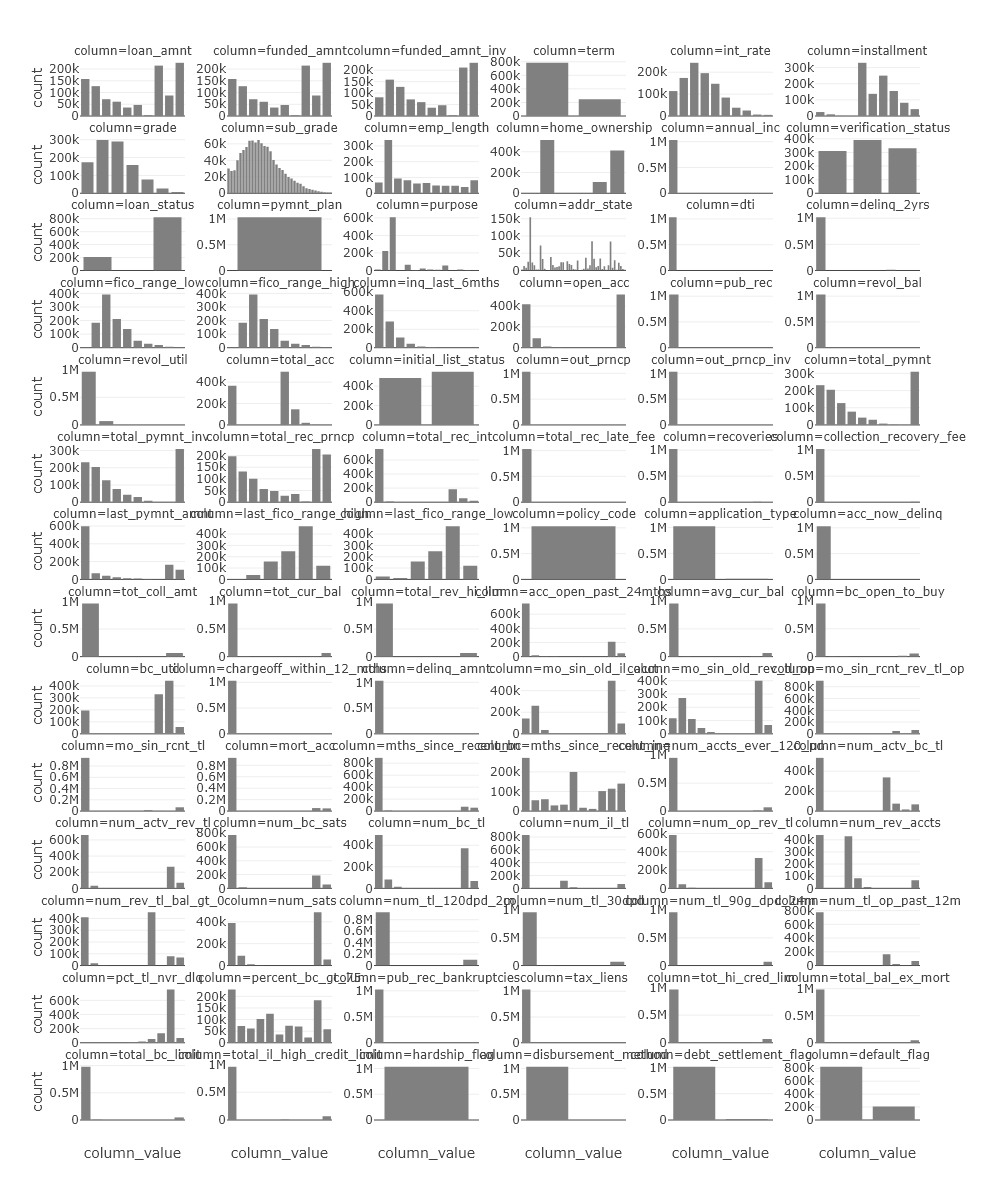

In [ ]:
fig = px.bar(dist_df,
              x='column_value',
              y='count',
              facet_col='column',
              facet_col_wrap=6,
			  facet_col_spacing=0.05,
			  facet_row_spacing=0.02,
              color_discrete_sequence=['gray'],
              template='none',
              width=1000,
              height=1200)

fig.update_xaxes(matches=None, showticklabels=False)
fig.update_yaxes(matches=None, showticklabels=True)
Image(fig.to_image('png'))

Although some columns have low variability, we will keep them

## Train Test Split
With the final dataset filtered and the starter features we will do the train/test split

In [ ]:
train_df, test_df = train_test_split(data_clean, train_size=0.60, random_state=42)
train_df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,default_flag
count,619801.000000,619801.000000,619801.000000,619801.000000,619801.000000,6.198010e+05,619723.000000,619801.000000,619801.000000,619801.000000,...,579231.000000,579158.000000,585085.000000,619394.000000,619774.000000,5.792310e+05,5.914490e+05,5.914490e+05,5.792310e+05,619801.000000
mean,14347.997825,14336.887606,14309.525875,0.133762,437.038457,7.574895e+04,18.058885,0.313749,695.633219,699.633337,...,2.199516,94.260307,46.360888,0.134443,0.049147,1.731781e+05,4.921218e+04,2.113642e+04,4.154543e+04,0.203806
std,8587.990801,8582.843686,8586.056588,0.047030,258.211968,6.938874e+04,9.799505,0.872129,31.485843,31.486404,...,1.841116,8.583865,35.798718,0.379241,0.377704,1.764632e+05,4.712481e+04,2.105694e+04,4.259491e+04,0.402827
min,500.000000,500.000000,0.000000,0.053100,4.930000,0.000000e+00,0.000000,0.000000,625.000000,629.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,8000.000000,8000.000000,7925.000000,0.099900,250.100000,4.550000e+04,11.710000,0.000000,670.000000,674.000000,...,1.000000,91.700000,14.300000,0.000000,0.000000,4.930000e+04,2.091100e+04,7.550000e+03,1.451600e+04,0.000000
50%,12000.000000,12000.000000,12000.000000,0.129900,375.710000,6.500000e+04,17.490000,0.000000,690.000000,694.000000,...,2.000000,98.000000,50.000000,0.000000,0.000000,1.122450e+05,3.710500e+04,1.480000e+04,3.132200e+04,0.000000
75%,20000.000000,20000.000000,20000.000000,0.162400,577.850000,9.000000e+04,23.840000,0.000000,710.000000,714.000000,...,3.000000,100.000000,75.000000,0.000000,0.000000,2.504390e+05,6.196800e+04,2.750000e+04,5.591700e+04,0.000000
max,40000.000000,40000.000000,40000.000000,0.309900,1719.830000,9.550000e+06,999.000000,39.000000,845.000000,850.000000,...,32.000000,100.000000,100.000000,12.000000,85.000000,9.999999e+06,3.408095e+06,1.105500e+06,2.101913e+06,1.000000


In [ ]:
test_df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,default_flag
count,413201.000000,413201.000000,413201.000000,413201.000000,413201.000000,4.132010e+05,413149.000000,413201.000000,413201.000000,413201.000000,...,386244.000000,386173.000000,389987.000000,412911.000000,413189.000000,3.862440e+05,3.942720e+05,394272.000000,3.862440e+05,413201.000000
mean,14365.949078,14355.215379,14327.385595,0.133663,437.471804,7.558192e+04,18.067478,0.313983,695.714241,699.714386,...,2.195809,94.263449,46.295224,0.133716,0.050829,1.733206e+05,4.918072e+04,21170.169533,4.152538e+04,0.202376
std,8595.954920,8590.471080,8594.858383,0.046952,258.489842,6.418803e+04,9.703957,0.866001,31.453558,31.454250,...,1.833186,8.559826,35.817045,0.376870,0.406698,1.772972e+05,4.689191e+04,21060.502561,4.260270e+04,0.401772
min,500.000000,500.000000,0.000000,0.053100,16.470000,0.000000e+00,-1.000000,0.000000,630.000000,634.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000
25%,8000.000000,8000.000000,7950.000000,0.099900,250.290000,4.550000e+04,11.740000,0.000000,670.000000,674.000000,...,1.000000,91.700000,14.300000,0.000000,0.000000,4.925800e+04,2.089275e+04,7600.000000,1.450000e+04,0.000000
50%,12000.000000,12000.000000,12000.000000,0.129900,376.370000,6.500000e+04,17.500000,0.000000,690.000000,694.000000,...,2.000000,98.000000,50.000000,0.000000,0.000000,1.122940e+05,3.710500e+04,14800.000000,3.125000e+04,0.000000
75%,20000.000000,20000.000000,20000.000000,0.162000,578.210000,9.000000e+04,23.840000,0.000000,710.000000,714.000000,...,3.000000,100.000000,75.000000,0.000000,0.000000,2.507702e+05,6.195300e+04,27500.000000,5.581100e+04,0.000000
max,40000.000000,40000.000000,40000.000000,0.309900,1714.540000,9.225000e+06,999.000000,30.000000,845.000000,850.000000,...,30.000000,100.000000,100.000000,8.000000,63.000000,9.999999e+06,2.921551e+06,684000.000000,2.000000e+06,1.000000


## Feature segmentation and Woe
This is necessary only for log reg

### TreeClassifier class
We will define a class that will segment the numeric columns, it will use a segmentation tree to define the segments and calculate the WOE

In [ ]:
class TreeClassifierBinner:
    def __init__(self,
                 data: pd.DataFrame, 
                 col_to_bin: str, 
                 target_col: str,
                 min_samples_split : float = 0.3,
                 max_leaf_nodes: int = 10):
        self.col_to_bin = col_to_bin
        self.target_col = target_col
        self.max_leaf_nodes = max_leaf_nodes
        self.min_samples_split = min_samples_split
        self.clf = DecisionTreeClassifier(max_leaf_nodes=self.max_leaf_nodes, random_state=0)
        self.data = data
        self.x = data[[self.col_to_bin]]
        self.y = data[self.target_col]
        self.clf.fit(self.x, self.y)
        self.univariate_thresholds = self.uniVariableDecisionTreeThresholds()
        self.calculateWoe()
    
    def plot(self):
        tree.plot_tree(self.clf)

    def uniVariableDecisionTreeThresholds(self):
        self.text_tree = tree.export_text(self.clf, feature_names=[self.col_to_bin])
        result = str(self.text_tree)
        result = result.replace(f"{self.col_to_bin}", "")
        result = re.sub("class: [0-9]", "", result)
        result = re.sub("[^0-9., ]", "", result)
        result = re.sub(" +", ", ", result.strip()).split(", ")
        result = list(set([float(x) for x in result])) + [float("-inf"), float("+inf")]
        result.sort()
        return result
    
    def withBands(self, df):
        result = df.copy()
        result[f'{self.col_to_bin}'] = result[f'{self.col_to_bin}'].fillna(result[f'{self.col_to_bin}'].mean())
        result[f'{self.col_to_bin}_bands'] = pd.cut(result[self.col_to_bin], self.univariate_thresholds, labels=False)
        return result

    def defaultRatesByGroups(self, df):
        result = df.groupby(f'{self.col_to_bin}_bands', observed=False)[self.target_col].agg(['count', 'sum'])
        result['total_count'] = result['count'].sum()
        result['m_rate'] = result['sum'] / result['count']
        return result.reset_index()
    
    def calculateWoe(self):
        grouped_data = self.data\
            .pipe(self.withBands)\
            .pipe(self.defaultRatesByGroups)
        grouped_data['non_defaults'] = grouped_data['count'] - grouped_data['sum']
        total_defaults = grouped_data['sum'].sum()
        total_non_defaults = grouped_data['non_defaults'].sum()
        grouped_data['perc_defaults'] = np.clip(grouped_data['sum'] / total_defaults, 0.00001, 0.99999)
        grouped_data['perc_non_defaults'] = np.clip(grouped_data['non_defaults'] / total_non_defaults, 0.00001, 0.99999)
        grouped_data['woe'] = np.log(grouped_data['perc_defaults'] / grouped_data['perc_non_defaults'])
        grouped_data['iv'] = np.sum(-grouped_data['woe'] * (grouped_data['perc_non_defaults'] - grouped_data['perc_defaults']))
        self.woe = grouped_data[[f'{self.col_to_bin}_bands', 'woe', 'iv']]
    
    def addWoeColumn(self, df, na_values = None):
        result = df.pipe(self.withBands)
        result = result.merge(
            self.woe,
            how='left',
            on=f'{self.col_to_bin}_bands'
        )
        result = result.drop(columns=['iv'])
        result = result.rename(columns={'woe':f'{self.col_to_bin}_woe'})
        if na_values:
          result[f'{self.col_to_bin}_woe'] = result[f'{self.col_to_bin}_woe'].fillna(na_values)
        return result
    

dl_binner = TreeClassifierBinner(train_df, 'num_rev_tl_bal_gt_0', 'default_flag', max_leaf_nodes=3)
print(dl_binner.univariate_thresholds)
dl_binner.woe

[-inf, 5.5, 10.5, inf]


,num_rev_tl_bal_gt_0_bands,woe,iv
0,0,-0.114486,0.022749
1,1,0.062953,0.022749
2,2,0.430922,0.022749


### CategoryClassifier
This classifier will be used for category features, it will use K-means to group the categories in segments and calculate WoE and IV

In [ ]:
class categoryClassifierBinner:
    def __init__(self,
                 data: pd.DataFrame, 
                 col_to_bin: str, 
                 target_col: str,
                 n_splits : int = 10,
                 n_samples: int = 10000,
                 n_groups:  int = 50):
        self.n_splits = n_splits
        self.col_to_bin = col_to_bin
        self.target_col = target_col
        self.data = data
        self.n_samples = n_samples
        self.n_groups = n_groups
        self.applyKMeans()
        self.calculateWoe()
        
    def applyKMeans(self):
        sample = self.data\
		.pipe(self.withDFResampled, self.n_samples, self.n_groups)\
		.pipe(self.defaultRatesByGroups, [self.col_to_bin, 'groups'])
        
        k_fold_sample = pd.pivot_table(sample, values='m_rate', index=self.col_to_bin, columns='groups').reset_index().set_index(self.col_to_bin)
        kmeans = KMeans(n_clusters=self.n_splits, random_state=42).fit(k_fold_sample)
        k_fold_sample['k_fold_groups'] = kmeans.predict(k_fold_sample)
        k_fold_sample = k_fold_sample.reset_index()
        self.groups_dict = k_fold_sample[[self.col_to_bin, 'k_fold_groups']].set_index(self.col_to_bin).to_dict()
        self.clusters = {}
        for group_i in k_fold_sample['k_fold_groups'].drop_duplicates():
            self.clusters[group_i] = k_fold_sample[k_fold_sample['k_fold_groups']==group_i][self.col_to_bin].to_list()
    
    def withDFResampled(self, df, n_samples, n_groups):
        sample = df.copy()
        sample[self.col_to_bin] = sample[self.col_to_bin].fillna("None")
        sample = sample[[self.col_to_bin, self.target_col]].groupby(self.col_to_bin).sample(n_samples, replace=True, random_state=42).reset_index(drop=True)
        sample['count'] = sample.groupby(self.col_to_bin)[self.target_col].expanding().count().reset_index()[self.target_col]
        sample['groups'] = pd.cut(sample['count'], n_groups, labels=False)
        return sample
          
    def withBands(self, df):
        result = df.copy()
        result[self.col_to_bin] = result[self.col_to_bin].fillna("None")
        result[f'{self.col_to_bin}_bands'] = result[self.col_to_bin].map(self.groups_dict['k_fold_groups'])
        return result

    def defaultRatesByGroups(self, df, col_list: list):
        result = df.groupby(col_list, observed=False)[self.target_col].agg(['count', 'sum'])
        result['total_count'] = result['count'].sum()
        result['m_rate'] = np.clip(result['sum'] / result['count'], 0.00001, None)
        return result.reset_index()
    
    def calculateWoe(self):
        grouped_data = self.data\
            .pipe(self.withBands)\
            .pipe(self.defaultRatesByGroups, [f"{self.col_to_bin}_bands"])
        grouped_data['non_defaults'] = grouped_data['count'] - grouped_data['sum']
        total_defaults = grouped_data['sum'].sum()
        total_non_defaults = grouped_data['non_defaults'].sum()
        grouped_data['perc_defaults'] = np.clip(grouped_data['sum'] / total_defaults, 0.00001, 0.99999)
        grouped_data['perc_non_defaults'] = np.clip(grouped_data['non_defaults'] / total_non_defaults, 0.00001, 0.99999)
        grouped_data['woe'] = np.log(grouped_data['perc_defaults'] / grouped_data['perc_non_defaults'])
        grouped_data['iv'] = np.sum(-grouped_data['woe'] * (grouped_data['perc_non_defaults'] - grouped_data['perc_defaults']))
        self.woe = grouped_data[[f'{self.col_to_bin}_bands', 'woe', 'iv']]
    
    def addWoeColumn(self, df, na_values = None):
        result = df.pipe(self.withBands)
        result = result.merge(
            self.woe,
            how='left',
            on=f'{self.col_to_bin}_bands'
        )
        result = result.drop(columns=['iv'])
        result = result.rename(columns={'woe':f'{self.col_to_bin}_woe'})
        if na_values:
          result[f'{self.col_to_bin}_woe'] = result[f'{self.col_to_bin}_woe'].fillna(na_values)
        return result

cat_binner = categoryClassifierBinner(train_df, 'sub_grade', 'default_flag', n_splits=10)
print(cat_binner.clusters)


{8: ['A1', 'A2', 'A3', 'A4'], 4: ['A5'], 2: ['B1', 'B2', 'B3', 'B4'], 6: ['B5', 'C1', 'C2', 'C3'], 0: ['C4', 'C5', 'D1'], 5: ['D2', 'D3', 'D4', 'D5'], 3: ['E1', 'E2', 'E3', 'E4', 'E5', 'F1'], 7: ['F2', 'G2', 'G4'], 1: ['F3', 'G1'], 9: ['F4', 'F5', 'G3', 'G5']}


In [ ]:
cat_binner.clusters

{8: ['A1', 'A2', 'A3', 'A4'],
 4: ['A5'],
 2: ['B1', 'B2', 'B3', 'B4'],
 6: ['B5', 'C1', 'C2', 'C3'],
 0: ['C4', 'C5', 'D1'],
 5: ['D2', 'D3', 'D4', 'D5'],
 3: ['E1', 'E2', 'E3', 'E4', 'E5', 'F1'],
 7: ['F2', 'G2', 'G4'],
 1: ['F3', 'G1'],
 9: ['F4', 'F5', 'G3', 'G5']}

### Generic Class to run for all variables
We will now define a class that can use both the TreeClassifier and CategoryClassifier, optimise the number of segments, calculate the IV, select features based in IV and eliminate highly correlated features

In [ ]:
class binnerSelector:
    def __init__(self,
                 data: pd.DataFrame,
                 cols_to_bin: list,
                 target_col: str,
                 iv_threshold: float = 0.02):
        self.data = data
        self.cols_to_bin = cols_to_bin
        self.cols_dict = self.data[cols_to_bin].dtypes.to_dict()
        self.target_col = target_col
        self.removed_cols = {}
        self.selected_cols = {}
        self.runForAllCols()
        self.iv_threshold = iv_threshold
        self.removeFeaturesWithLowIV()
    
    def binCol(self, col_i, n_splits):
        if self.cols_dict[col_i] in ['float', 'int']:
            cat_binner = TreeClassifierBinner(self.data, col_i, self.target_col, max_leaf_nodes=n_splits, min_samples_split=0.01)
        else:
            cat_binner = categoryClassifierBinner(self.data, col_i, self.target_col, n_splits=n_splits, n_samples=10000, n_groups=50)
        return cat_binner
    
    def selectCategBestBin(self, col_i):
        results = {}
        n_split = 5
        max_splits = len(self.data[col_i].drop_duplicates())
        if max_splits < 3:
            n_split = max_splits
            results[max_splits] = self.binCol(col_i, max_splits)
            print(f"No better adjustment found: bins: {n_split}, iv: {results[n_split].woe['iv'][0]}")
            results['best'] = results[n_split]
            return results
        elif n_split  >= max_splits:
            n_split = max_splits - 1
        print(f"starting binnin for column: {col_i}")
        results[n_split] = self.binCol(col_i, n_split)
        results[n_split+1] = self.binCol(col_i, n_split+1)
        results[n_split-1] = self.binCol(col_i, n_split-1)
        while results[n_split+1].woe['iv'][0] > results[n_split].woe['iv'][0]:
            if n_split + 2 > max_splits:
                n_split = n_split + 1
                print("reached maximun splits")
                break
            print(f"bins: {n_split}, iv: {results[n_split].woe['iv'][0]}")
            print(f"bins: {n_split+1}, iv: {results[n_split+1].woe['iv'][0]}")
            n_split = n_split + 1
            results[n_split+1] = self.binCol(col_i, n_split+1)
            if n_split + 3 > max_splits:
                n_split = n_split + 1
                print("reached maximun splits")
                break
        while results[n_split-1].woe['iv'][0] > results[n_split].woe['iv'][0]:
            if n_split - 1 < 3:
                print("reached minimum splits")
                break
            else:
                print(f"bins: {n_split}, iv: {results[n_split].woe['iv'][0]}")
                print(f"bins: {n_split-1}, iv: {results[n_split-1].woe['iv'][0]}")
                n_split = n_split-1
                results[n_split-1] = self.binCol(col_i, n_split-1)
        else:
            print(f"No better adjustment found: bins: {n_split}, iv: {results[n_split].woe['iv'][0]}")
            results['best'] = results[n_split]
        return results
    
    def selectMonotonicBestBin(self, col_i):
        results = {}
        n_split = 5
        max_splits = len(self.data[col_i].drop_duplicates())
        print(f"starting binnin for column: {col_i}")
        if max_splits == 1:
            self.removed_cols[col_i] = 'unique value'
            print("unique value, variable removed")
            return None
        results[n_split] = self.binCol(col_i, n_split)
        results[n_split+1] = self.binCol(col_i, n_split+1)
        results[n_split-1] = self.binCol(col_i, n_split-1)
        while results[n_split+1].woe['iv'][0] > results[n_split].woe['iv'][0]:
            print(f"bins: {n_split}, iv: {results[n_split].woe['iv'][0]}")
            print(f"bins: {n_split+1}, iv: {results[n_split+1].woe['iv'][0]}")
            if results[n_split+1].woe['woe'].is_monotonic_decreasing or results[n_split+1].woe['woe'].is_monotonic_increasing:
                n_split = n_split + 1
                results[n_split+1] = self.binCol(col_i, n_split+1)
            else:
                print(f"bins: {n_split + 1} has no monotonic behaviour")
                break
        while results[n_split-1].woe['iv'][0] > results[n_split].woe['iv'][0] \
        or (results[n_split].woe['woe'].is_monotonic_increasing == False\
        and results[n_split].woe['woe'].is_monotonic_decreasing == False):
            if n_split - 1 <= 2:
                print("reached minimum split")
                n_split = n_split -1
                break
            else:
                print(f"bins: {n_split}, iv: {results[n_split].woe['iv'][0]}")
                print(f"bins: {n_split-1}, iv: {results[n_split-1].woe['iv'][0]}")
                n_split = n_split-1
                results[n_split-1] = self.binCol(col_i, n_split-1)
        
        print(f"No better adjustment found: bins: {n_split}, iv: {results[n_split].woe['iv'][0]}")
        results['best'] = results[n_split]
        return results
    
    def runForAllCols(self):
        self.results_per_column = {}
        for col_i in self.cols_to_bin:
            if self.cols_dict[col_i] in ['float', 'int']:
                result = self.selectMonotonicBestBin(col_i)
                if result:
                    self.results_per_column[col_i] = result
            else:
                self.results_per_column[col_i] = self.selectCategBestBin(col_i)
    
    def removeFeaturesWithLowIV(self):
        self.ivs = []
        for i, col_i in enumerate(self.results_per_column):
            self.ivs.append({'variable': col_i, 'iv':self.results_per_column[col_i]['best'].woe['iv'][0]})
            if self.results_per_column[col_i]['best'].woe['iv'][0] > self.iv_threshold:
                self.selected_cols[col_i] = self.results_per_column[col_i]['best']
            else:
                self.removed_cols[col_i] = "low IV"
        self.ivs = pd.DataFrame(self.ivs, columns=['variable', 'iv'])
        print(f"selected cols: {len(self.selected_cols.keys())}")
        print(f"removed cols: {len(self.removed_cols.keys())}")

    def addWoeColumn(self, df):
        result = df.copy()
        for col_i, cat_binner_i in self.selected_cols.items():
            result = cat_binner_i.addWoeColumn(result)
        return result
    
    def removeHighlyCorrelatedFeatures(self):
        df = self.data
        woe_col_list = [f"{col_i}_woe" for col_i in self.selected_cols.keys()]
        woe_df = self.addWoeColumn(df)[woe_col_list]
        corr = woe_df.corr()
        self.corr = corr
        corr = corr.reset_index().melt(id_vars='index')
        highCorr = corr[(corr['index']!=corr['variable'])
                        &(np.abs(corr['value']) > 0.7)]\
                        .reset_index(drop=True)
        highCorr['variable'] = highCorr['variable'].str.replace("_woe", "")
        highCorr['index'] = highCorr['index'].str.replace("_woe", "")
        highCorr = highCorr.merge(
            self.ivs,
            how='left',
            on='variable'
        ).merge(
            self.ivs,
            how='left',
            right_on='variable',
            left_on='index',
            suffixes=['_1', '_2']
        )
        highCorr['dropped_variables'] = np.where(highCorr['iv_1'] < highCorr['iv_2'], highCorr['variable_1'], highCorr['variable_2'])
        self.highCorr = highCorr
        dropped_cols = highCorr.sort_values("value")[::2]['dropped_variables'].drop_duplicates()
        for col_i in dropped_cols:
            self.removed_cols[col_i] = "high correl"
            del self.selected_cols[col_i]
        print(f"removed {len(dropped_cols)} cols due to high corr")
        print(f"selected cols: {len(self.selected_cols)}")

#### Run on all variables

In [ ]:
cols_to_bin = \
['loan_amnt', 
 'funded_amnt', 
 'funded_amnt_inv', 
 'term', 
 'int_rate',
 'installment', 
 'grade', 
 'sub_grade', 
 'emp_length', 
 'home_ownership',
 'annual_inc', 
 'verification_status', 
 'pymnt_plan',
 'purpose', 
 'addr_state', 
 'dti', 
 'delinq_2yrs', 
 'fico_range_low',
 'fico_range_high', 
 'inq_last_6mths',
 'open_acc', 
 'pub_rec', 
 'revol_bal',
 'revol_util', 
 'total_acc', 
 'initial_list_status', 
#  'out_prncp',
#  'out_prncp_inv', 
#  'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
# 'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt', 'last_fico_range_high',
# 'last_fico_range_low', 'policy_code', 'application_type',
# 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
# 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
# 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
# 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
# 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq',
# 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
# 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
# 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
# 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
# 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
# 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
# 'total_il_high_credit_limit', 'hardship_flag', 'disbursement_method',
# 'debt_settlement_flag'
]

#columns above will not be analysed due to the possibility of data leakage

cat_binner = binnerSelector(train_df, cols_to_bin, 'default_flag')

starting binnin for column: loan_amnt
bins: 5, iv: 0.03380235569799378
bins: 6, iv: 0.03491724507760852
bins: 6 has no monotonic behaviour
bins: 5, iv: 0.03380235569799378
bins: 4, iv: 0.03271092834327666
No better adjustment found: bins: 4, iv: 0.03271092834327666
starting binnin for column: funded_amnt
bins: 5, iv: 0.033853801500477856
bins: 6, iv: 0.03495547511638106
bins: 6 has no monotonic behaviour
bins: 5, iv: 0.033853801500477856
bins: 4, iv: 0.032763307859847046
No better adjustment found: bins: 4, iv: 0.032763307859847046
starting binnin for column: funded_amnt_inv
bins: 5, iv: 0.03351699478592412
bins: 6, iv: 0.03469371299187386
bins: 6 has no monotonic behaviour
bins: 5, iv: 0.03351699478592412
bins: 4, iv: 0.032509077661596684
No better adjustment found: bins: 4, iv: 0.032509077661596684
No better adjustment found: bins: 2, iv: 0.17054003913996021
starting binnin for column: int_rate
bins: 5, iv: 0.3689684309669597
bins: 6, iv: 0.40811385252778853
bins: 6, iv: 0.4081138525

#### Drop Highly Correlated Features

In [ ]:
cat_binner.removeHighlyCorrelatedFeatures()

removed 6 cols due to high corr
selected cols: 10


In [ ]:
cat_binner.highCorr

,index,variable_1,value,iv_1,variable_2,iv_2,dropped_variables
0,funded_amnt,loan_amnt,0.999561,0.032711,funded_amnt,0.032763,loan_amnt
1,funded_amnt_inv,loan_amnt,0.997688,0.032711,funded_amnt_inv,0.032509,funded_amnt_inv
2,installment,loan_amnt,0.881013,0.032711,installment,0.027771,installment
3,loan_amnt,funded_amnt,0.999561,0.032763,loan_amnt,0.032711,loan_amnt
4,funded_amnt_inv,funded_amnt,0.998185,0.032763,funded_amnt_inv,0.032509,funded_amnt_inv
5,installment,funded_amnt,0.881582,0.032763,installment,0.027771,installment
6,loan_amnt,funded_amnt_inv,0.997688,0.032509,loan_amnt,0.032711,funded_amnt_inv
7,funded_amnt,funded_amnt_inv,0.998185,0.032509,funded_amnt,0.032763,funded_amnt_inv
8,installment,funded_amnt_inv,0.878759,0.032509,installment,0.027771,installment
9,grade,int_rate,0.948890,0.418877,grade,0.451312,int_rate


In [ ]:
fig = px.imshow(cat_binner.corr, 
                text_auto=True, 
                template = 'none', 
                zmax = 1, 
                zmin=-1,
                height=1000)
fig.update_traces(texttemplate = '%{z:0.1%}')
fig.update_coloraxes(colorscale=[[0, 'rgb(255,102,102)'], [0.5, 'rgb(255,255,255)'], [1, 'rgb(102,102,255)']])
fig

In [ ]:
cat_binner.selected_cols

{'funded_amnt': <__main__.TreeClassifierBinner at 0x1f0cda69550>,
 'term': <__main__.categoryClassifierBinner at 0x1f086364ce0>,
 'sub_grade': <__main__.categoryClassifierBinner at 0x1f0d21964e0>,
 'home_ownership': <__main__.categoryClassifierBinner at 0x1f0cda68a40>,
 'annual_inc': <__main__.TreeClassifierBinner at 0x1f0d211cd10>,
 'verification_status': <__main__.categoryClassifierBinner at 0x1f0d2184c20>,
 'dti': <__main__.TreeClassifierBinner at 0x1f0cdac6ed0>,
 'fico_range_low': <__main__.TreeClassifierBinner at 0x1f0cda8bf50>,
 'inq_last_6mths': <__main__.TreeClassifierBinner at 0x1f0cd9f4560>,
 'revol_util': <__main__.TreeClassifierBinner at 0x1f0cdaaa870>}

#### Calculate WoE columns
We will use the class created and now create the WoE columns of the selected features, we will also save both train and test DF with these columns.
<br>We will also save the cat_binner class so we can use it later if necessary

In [ ]:
train_df_woe = cat_binner.addWoeColumn(train_df)
train_df_woe.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,verification_status_bands,verification_status_woe,dti_bands,dti_woe,fico_range_low_bands,fico_range_low_woe,inq_last_6mths_bands,inq_last_6mths_woe,revol_util_bands,revol_util_woe
0,7400.0,7400.0,7400.0,36 months,0.1825,268.46,E,E1,10+ years,MORTGAGE,...,1,-0.403293,5,0.339305,14,-0.514567,0,-0.134986,0,-0.456498
1,6000.0,6000.0,6000.0,36 months,0.0958,192.43,B,B1,None,MORTGAGE,...,0,0.078777,5,0.339305,12,-0.381965,1,0.083006,0,-0.456498
2,8500.0,8500.0,8500.0,36 months,0.0699,262.42,A,A2,10+ years,MORTGAGE,...,1,-0.403293,3,0.002166,7,-0.019309,1,0.083006,3,-0.062727
3,20000.0,20000.0,20000.0,36 months,0.1049,649.96,B,B3,10+ years,MORTGAGE,...,1,-0.403293,1,-0.248982,6,0.062224,0,-0.134986,1,-0.350623
4,15000.0,15000.0,15000.0,36 months,0.1099,491.01,B,B4,2 years,MORTGAGE,...,1,-0.403293,3,0.002166,11,-0.318577,0,-0.134986,5,0.103752


In [ ]:
test_df_woe = cat_binner.addWoeColumn(test_df)
test_df_woe.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,verification_status_bands,verification_status_woe,dti_bands,dti_woe,fico_range_low_bands,fico_range_low_woe,inq_last_6mths_bands,inq_last_6mths_woe,revol_util_bands,revol_util_woe
0,20000.0,20000.0,20000.0,60 months,0.1699,496.95,D,D3,10+ years,RENT,...,2,0.222800,7,0.742257,0,0.399710,0,-0.134986,6,0.157041
1,3000.0,3000.0,3000.0,36 months,0.1114,98.42,B,B2,2 years,RENT,...,2,0.222800,1,-0.248982,17,-0.741141,0,-0.134986,1,-0.350623
2,12000.0,12000.0,12000.0,36 months,0.1099,392.81,B,B2,10+ years,MORTGAGE,...,0,0.078777,2,-0.130457,2,0.279531,1,0.083006,4,0.022404
3,10000.0,10000.0,10000.0,36 months,0.0789,312.86,A,A5,10+ years,OWN,...,1,-0.403293,0,-0.396663,18,-0.842398,0,-0.134986,1,-0.350623
4,2400.0,2400.0,2400.0,36 months,0.0819,75.42,A,A5,5 years,RENT,...,0,0.078777,6,0.530241,18,-0.842398,0,-0.134986,4,0.022404


In [ ]:
train_df_woe.to_parquet(f'{output_path}train_df.parquet')
test_df_woe.to_parquet(f'{output_path}test_df.parquet')

In [ ]:
joblib.dump(cat_binner, f'{output_path}cat_binner.gz')

['..\\..\\data\\outputs\\02_base_pipeline\\cat_binner.gz']